In [5]:
 
import numpy as np 
# 1. Definir uma matriz simétrica 
A = np.array([[4, 1, 2], [1, 5, 0], [2, 0, 3]]) 
# 2. Calcular Autovalores (w) e Autovetores (v) 
w, v = np.linalg.eigh(A) 
print(w)v# 3. Verificação da equação característica: A*v[:,0] == w[0]*v[:,0] 
autovetor_0 = v[:, 0] 
lado_esquerdo = A @ autovetor_0 
lado_direito = w[0] * autovetor_0  
print(np.allclose(lado_esquerdo, lado_direito))
print (autovetor_0)
print (autovetor_0)

True
[ 0.63117897 -0.17202654 -0.75632002]
[ 0.63117897 -0.17202654 -0.75632002]


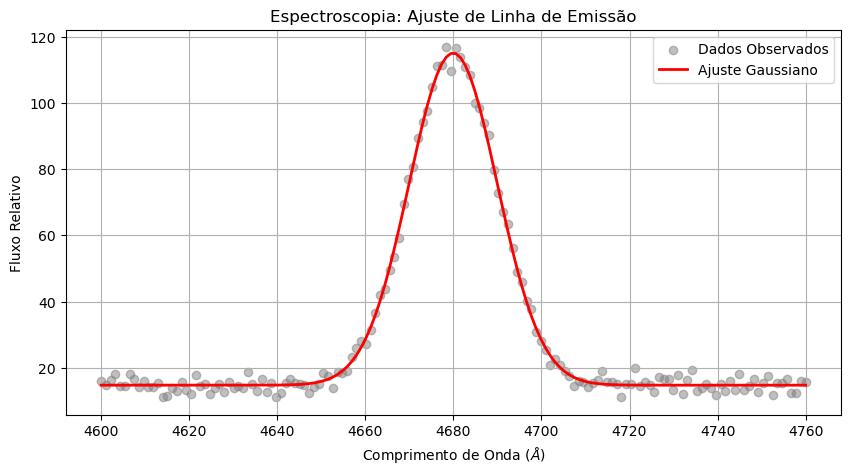

In [4]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit

# 1. Definição estrita do modelo físico vetorial
def modelo_gaussiano(x, amplitude, centro, largura, fundo):
    return amplitude * np.exp(-((x - centro)**2) / (2 * largura**2)) + fundo

# 2. Geração de dados de teste (Ajustado para criar x_dados e y_ruido que faltavam)
np.random.seed(42)
x_dados = np.linspace(4600, 4760, 150)
y_ruido = modelo_gaussiano(x_dados, 100, 4680, 10, 15) + np.random.normal(0, 2, 150)

# 3. O Ajuste 
chute_inicial = [100, 4680, 10, 15]
# Fechando os parênteses e adicionando p0 e os dados de y
parametros_otimizados, matriz_covariancia = curve_fit(modelo_gaussiano, x_dados, y_ruido, p0=chute_inicial)

# 4. Cálculo dos resíduos 
y_ajustado = modelo_gaussiano(x_dados, *parametros_otimizados) 
residuos = y_ruido - y_ajustado

# 5. Visualização Científica
plt.figure(figsize=(10, 5))
plt.scatter(x_dados, y_ruido, label='Dados Observados', color='gray', alpha=0.5)
plt.plot(x_dados, y_ajustado, label='Ajuste Gaussiano', color='red', linewidth=2)

plt.title("Espectroscopia: Ajuste de Linha de Emissão") 
plt.xlabel(r"Comprimento de Onda ($\AA$)") 
plt.ylabel("Fluxo Relativo")

plt.legend() 
plt.grid(True) 
plt.show()